In [12]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
df = pd.read_csv('CarPrice_Assignment.csv')

In [14]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [15]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    str    
 3   fueltype          205 non-null    str    
 4   aspiration        205 non-null    str    
 5   doornumber        205 non-null    str    
 6   carbody           205 non-null    str    
 7   drivewheel        205 non-null    str    
 8   enginelocation    205 non-null    str    
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    str    
 15  cylindernumber    205 non-null    str    
 16  enginesize        205 non-null    int64  
 17  fuelsyst

In [20]:
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [21]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [18]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df.duplicated().sum().sum()

np.int64(0)

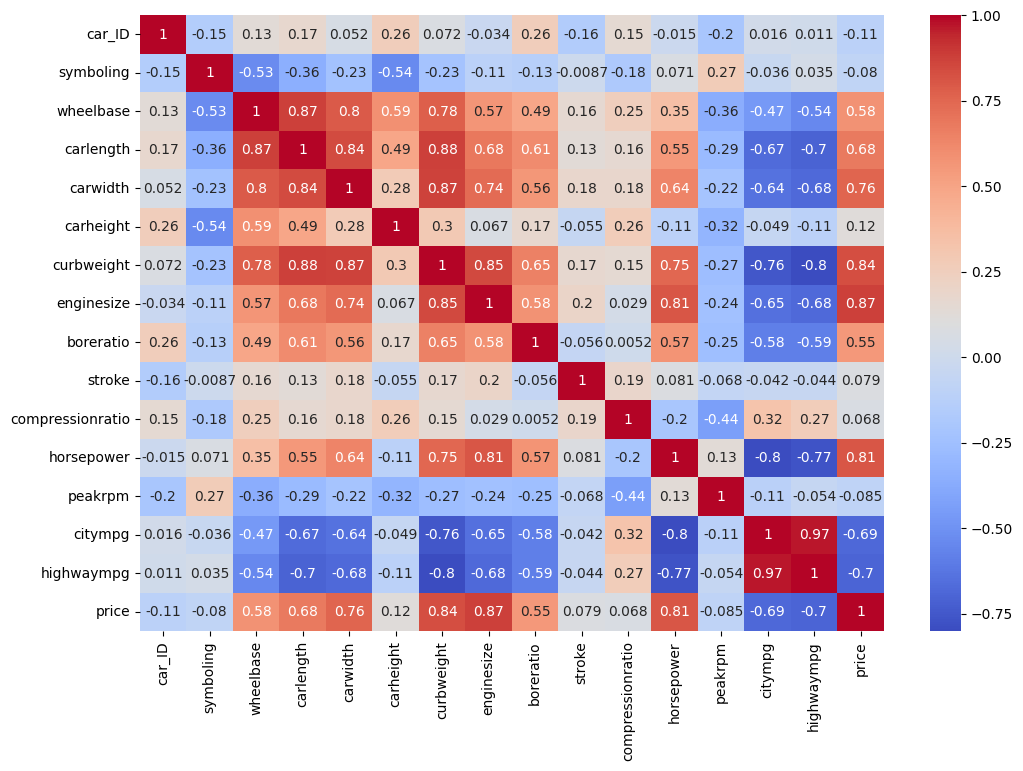

In [25]:
#Correlation analysis
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', annot=True)
plt.show()

In [17]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='str')

In [26]:
corr = df.corr(numeric_only=True)

corr['price'].sort_values(ascending=False)

price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
peakrpm            -0.085267
car_ID             -0.109093
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64

In [27]:
X = df[['enginesize', 'curbweight', 'horsepower', 'carwidth', 'carlength']]
y = df['price']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


Training set shape: (164, 5)
Testing set shape: (41, 5)


In [38]:
X_test

,enginesize,curbweight,horsepower,carwidth,carlength
15,209,3230,182,66.9,189.0
9,131,3053,160,67.9,178.2
100,120,2302,97,65.2,173.4
132,121,2658,110,66.5,186.6
68,183,3750,123,70.3,190.9
95,97,2028,69,63.8,165.6
159,110,2275,56,64.4,166.3
162,98,2140,70,64.4,166.3
147,108,2455,94,65.4,173.5
182,97,2261,52,65.5,171.7


In [39]:
y_test

15     30760.000
9      17859.167
100     9549.000
132    11850.000
68     28248.000
95      7799.000
159     7788.000
162     9258.000
147    10198.000
182     7775.000
191    13295.000
164     8238.000
65     18280.000
175     9988.000
73     40960.000
152     6488.000
18      5151.000
82     12629.000
86      8189.000
143     9960.000
60      8495.000
101    13499.000
98      8249.000
30      6479.000
25      6692.000
16     41315.000
168     9639.000
195    13415.000
97      7999.000
194    12940.000
67     25552.000
120     6229.000
154     7898.000
202    21485.000
79      7689.000
69     28176.000
145    11259.000
55     10945.000
45      8916.500
84     14489.000
146     7463.000
Name: price, dtype: float64

In [47]:
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModel training complete.")

# Print learned parameters
print("\nCoefficients (w):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef}")

print("\nIntercept (b):", model.intercept_)


Model training complete.

Coefficients (w):
enginesize: 77.45307393669086
curbweight: 2.406438020390169
horsepower: 52.530659808229885
carwidth: 652.6682762131677
carlength: -16.623252409827693

Intercept (b): -48350.72344500307


In [34]:
y_pred = model.predict(X_test)
print(y_pred)

[25692.05687193 18901.30246171 11250.23939297 13496.32480694
 24017.80375104  6554.52198231  7852.86824606  7333.99146338
 10660.26687343  7230.33505418 15032.79635596  7187.04038041
 15453.87948353 12223.91090386 37892.58958973  5752.42508609
  -513.4783491  18559.10006863 11327.38962632 10408.4613797
 11757.46871801 21482.86430681  6559.58762961  5245.74650654
  6003.94171715 26625.89923963 15039.73055219 16580.62625862
  6499.71296341 16287.04082013 23452.29081624  5951.0000807
  6231.33976519 21166.33225387  8785.0130733  23460.68111403
 11710.5770599   8174.88694967  5809.22689327 18782.89880453
  9632.83668236]


In [32]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 2699.737515820542
MSE : 14134655.788057005
RMSE: 3759.608462068491
R²  : 0.8209534347179518


The model is performing quite well. The R² score is 0.82, which means it is able to explain about 82% of the variation in car prices, so it has learned most of the pattern in the data. The MAE (Mean Absolute Error) is around 2700, meaning on average the predictions are off by about $2700. MSE (Mean Squared Error) is similar to MAE but it gives more weight to big mistakes, so large errors affect it more. The RMSE (Root Mean Squared Error) is about 3759, which shows the typical error range of the model. Overall, the model is decent for learning purposes, but it still makes noticeable errors and can be improved with better features or a stronger model.

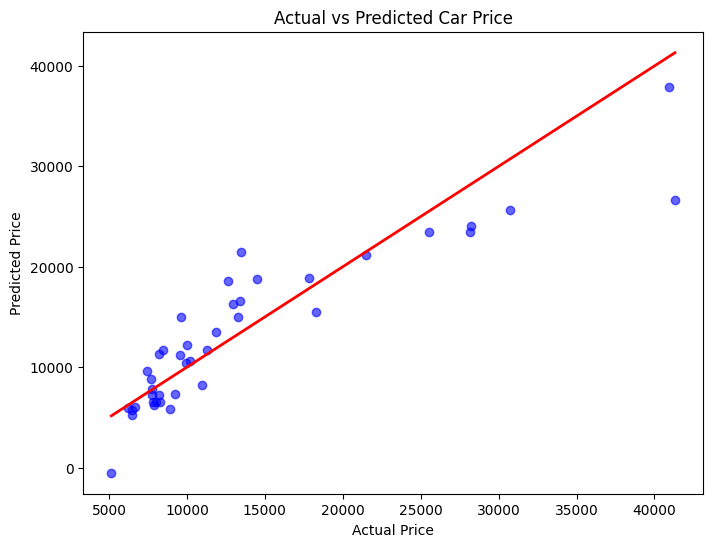

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, color='blue', alpha=0.6)

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=2)

plt.title('Actual vs Predicted Car Price')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.show()

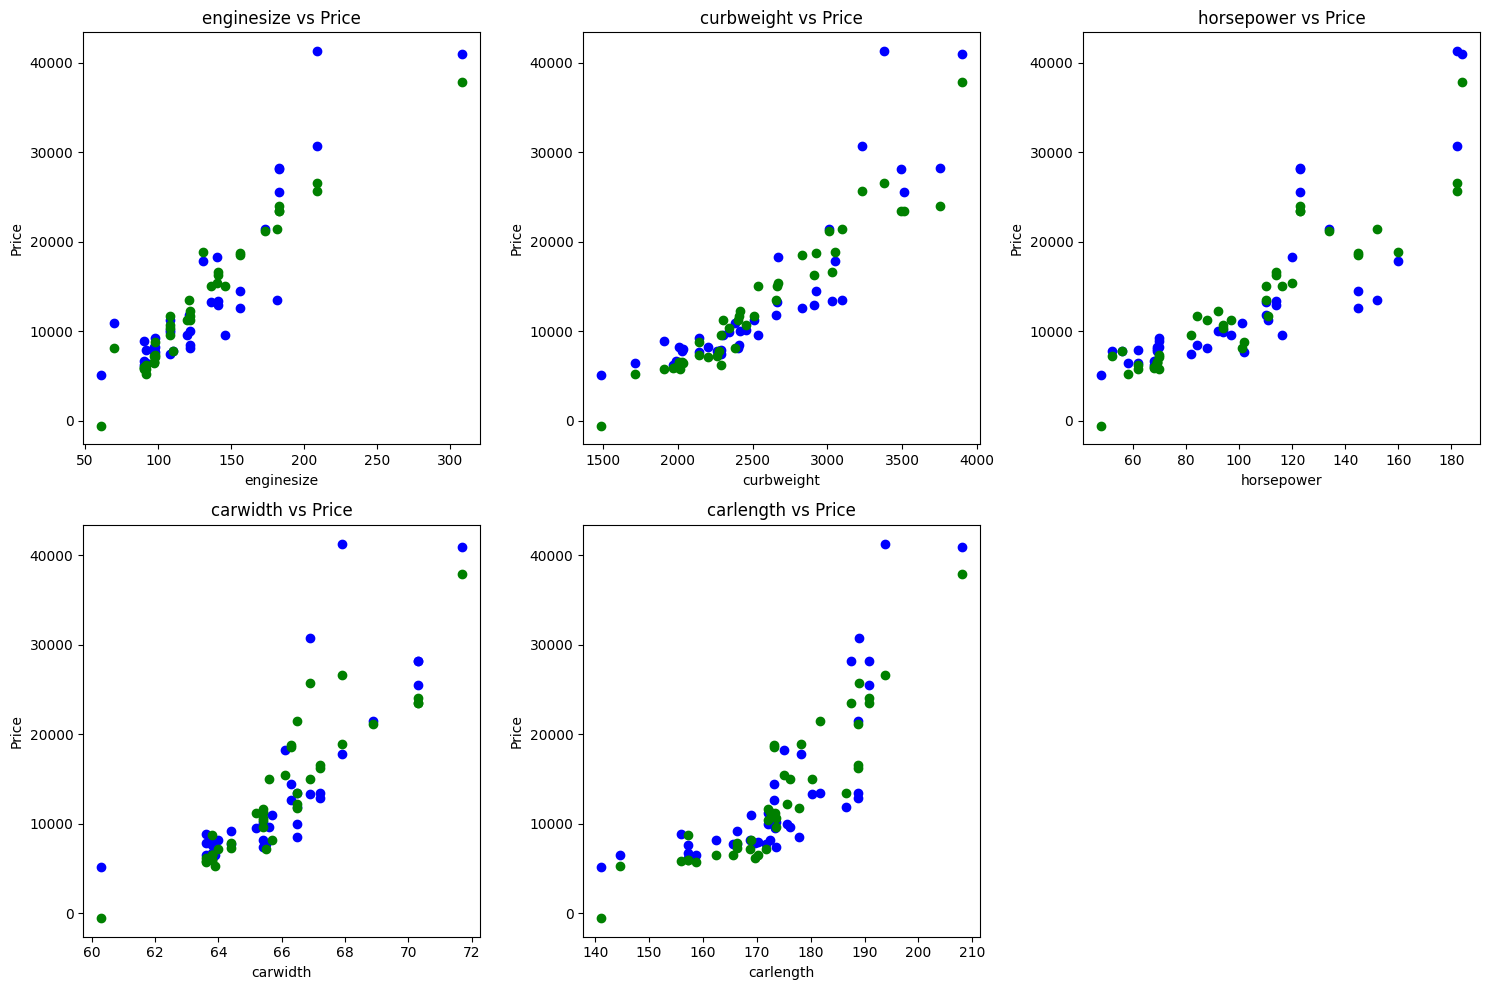

In [44]:
import matplotlib.pyplot as plt

features = X.columns

plt.figure(figsize=(15, 10))

for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)

    plt.scatter(X_test[feature], y_test, color='blue', label='Actual')
    plt.scatter(X_test[feature], y_pred, color='green', label='Predicted')

    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.title(f"{feature} vs Price")

plt.tight_layout()
plt.show()

In [50]:
comparison = pd.DataFrame({'Actual': y_test.values,'Predicted': y_pred})
comparison.head(10)

,Actual,Predicted
0,30760.000,25692.056872
1,17859.167,18901.302462
2,9549.000,11250.239393
3,11850.000,13496.324807
4,28248.000,24017.803751
5,7799.000,6554.521982
6,7788.000,7852.868246
7,9258.000,7333.991463
8,10198.000,10660.266873
9,7775.000,7230.335054


In [51]:
# 7. Make a new prediction
feature_names = ['enginesize', 'curbweight', 'horsepower', 'carwidth', 'carlength']
new_car = np.array([[130, 2500, 100, 65, 180]])
predicted_price = model.predict(new_car)

print(f"Predicted price: {predicted_price[0]:.2f}")

Predicted price: 12418.59


C:\Users\Asus\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
